In [1]:
pip install numpy matplotlib scikit-learn

Cluster Assignments:
A1 (np.int64(2), np.int64(10)) --> Cluster 1
A2 (np.int64(2), np.int64(5)) --> Cluster 2
A3 (np.int64(8), np.int64(4)) --> Cluster 0
B1 (np.int64(5), np.int64(8)) --> Cluster 1
B2 (np.int64(7), np.int64(5)) --> Cluster 0
B3 (np.int64(6), np.int64(4)) --> Cluster 0
C1 (np.int64(1), np.int64(2)) --> Cluster 2
C2 (np.int64(4), np.int64(9)) --> Cluster 1

Membership Probabilities:
A1: [4.09852765e-40 1.00000000e+00 0.00000000e+00]
A2: [2.68879222e-011 2.33640927e-237 1.00000000e+000]
A3: [1.00000000e+00 2.51071092e-47 0.00000000e+00]
B1: [4.93214676e-15 1.00000000e+00 0.00000000e+00]
B2: [1.00000000e+00 5.37961871e-33 0.00000000e+00]
B3: [1.00000000e+000 1.81807172e-112 0.00000000e+000]
C1: [9.13781172e-20 0.00000000e+00 1.00000000e+00]
C2: [8.34513952e-25 1.00000000e+00 0.00000000e+00]

Gaussian Means:
[[7.         4.33333333]
 [3.66666667 9.        ]
 [1.5        3.5       ]]


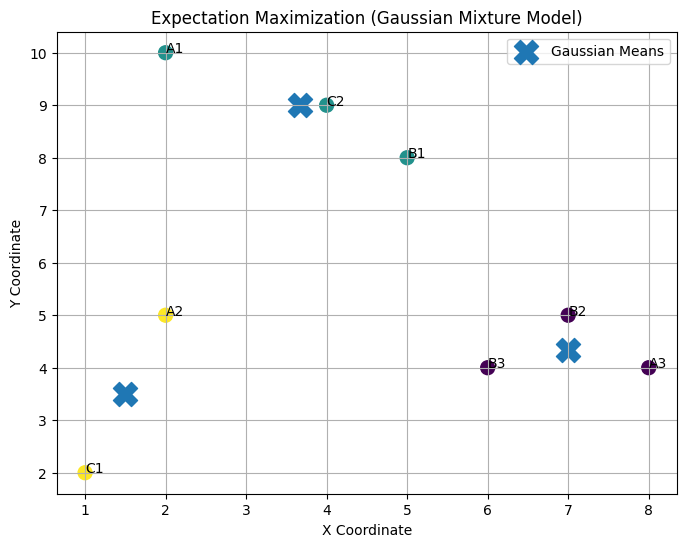

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# Dataset
X = np.array([
    [2, 10],  # A1
    [2, 5],   # A2
    [8, 4],   # A3
    [5, 8],   # B1
    [7, 5],   # B2
    [6, 4],   # B3
    [1, 2],   # C1
    [4, 9]    # C2
])

labels = ['A1', 'A2', 'A3', 'B1', 'B2', 'B3', 'C1', 'C2']

# Gaussian Mixture Model (EM Algorithm)
gmm = GaussianMixture(
    n_components=3,
    covariance_type='full',
    random_state=42
)

gmm.fit(X)

# Predict cluster labels
cluster_labels = gmm.predict(X)

# Cluster probabilities
probabilities = gmm.predict_proba(X)

# Display cluster assignments
print("Cluster Assignments:")
for i in range(len(X)):
    print(f"{labels[i]} {tuple(X[i])} --> Cluster {cluster_labels[i]}")

# Display cluster probabilities
print("\nMembership Probabilities:")
for i in range(len(X)):
    print(f"{labels[i]}: {probabilities[i]}")

# Means (cluster centers)
print("\nGaussian Means:")
print(gmm.means_)

# Plot clusters
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, s=100)

# Label points
for i, label in enumerate(labels):
    plt.annotate(label, (X[i, 0], X[i, 1]))

# Plot Gaussian means
plt.scatter(
    gmm.means_[:, 0],
    gmm.means_[:, 1],
    marker='X',
    s=300,
    label='Gaussian Means'
)

plt.title("Expectation Maximization (Gaussian Mixture Model)")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend()
plt.grid(True)
plt.show()